https://www.kaggle.com/competitions/titanic

# Titanic kaggle competition: first data analysis, feature engineering and predictions

In [8]:
import dotenv
import kagglehub
import pandas as pd
try:
    train = pd.read_csv("data/train.csv", index_col = "PassengerId")
    test = pd.read_csv("data/test.csv", index_col = "PassengerId")
except FileNotFoundError:
    dotenv.load_dotenv(dotenv.find_dotenv())
    kagglehub.login()
    kagglehub.competition_download("titanic", output_dir = "./data")

In [2]:
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Survived and Pclass are considered as int64, but they have a categorical meaning.
#I'll change the data types for now:
# train.dtypes
svclass = ["Survived","Pclass"]
for column in svclass:
    train[column] = train[column].astype(str)

In [4]:
print("Proportion of null values per column:")
null_proportion_per_col = train.isnull().sum()/train.shape[0]
print(null_proportion_per_col[null_proportion_per_col>0].sort_values(ascending=False))

Proportion of null values per column:
Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64


In [5]:
print("Proportion of null values per row:")
null_proportion_per_col = train.isnull().sum(axis=1)/train.shape[1]
print(null_proportion_per_col[null_proportion_per_col>0].sort_values(ascending=False))

Proportion of null values per row:
PassengerId
503    0.181818
182    0.181818
761    0.181818
389    0.181818
590    0.181818
         ...   
327    0.090909
329    0.090909
334    0.090909
339    0.090909
891    0.090909
Length: 708, dtype: float64


## 1. Exploratory data analysis (*EDA*)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1. Univariate *EDA*

#### Numerical variables

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


<AxesSubplot:>

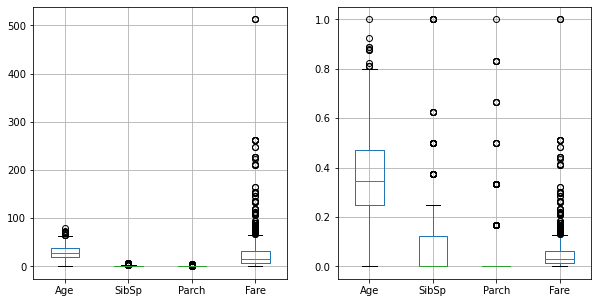

In [8]:
from sklearn.preprocessing import MinMaxScaler
plt.figure(figsize=(10,5))
plt.subplot(121)
train.boxplot()
scaler = MinMaxScaler()
num_cols = [col for col in train.columns if train[col].dtype!="object"]
train_scaled = scaler.fit_transform(train.loc[:,num_cols])
train_scaled = pd.DataFrame(train_scaled,columns=num_cols)
plt.subplot(122)
train_scaled.boxplot()

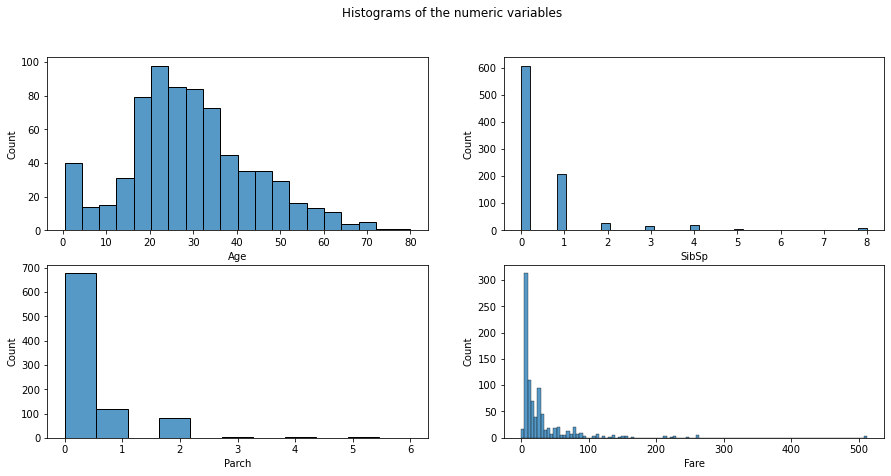

In [9]:
plt.figure(figsize=(15,7))
plt.suptitle("Histograms of the numeric variables")
i = 0
for col in num_cols:
    i+=1
    plt.subplot(2,2,i)
    sns.histplot(x=col,data=train)
plt.show()

# train_nums = train.loc[:,num_cols]
# melted_train_nums = train_nums.reset_index().melt(id_vars=["PassengerId"], value_vars=num_cols)
# sns.displot(data=melted_train_nums,x="value",col="variable")

Categorical variables

In [10]:
train_cats = train.loc[:,~train.columns.isin(num_cols)]
train_cats.describe()

,Survived,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891,204,889
unique,2,3,891,2,681,147,3
top,0,3,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,549,491,1,577,7,4,644


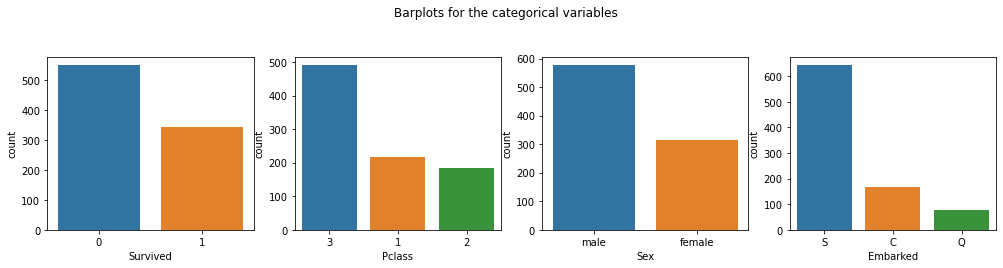

In [11]:
plt.figure(figsize=(17,7))
plt.suptitle("Barplots for the categorical variables")
i = 0
for col in ["Survived","Pclass","Sex","Embarked"]:
    i+=1
    plt.subplot(2,4,i)
    sns.countplot(x=col,data=train)
plt.show()

In [12]:
# non_unique_tickets = 
ticket_counts = train.groupby("Ticket").count()
repeated_tickets = ticket_counts[(ticket_counts>1).any(axis=1)].index
# print(repeated_tickets)
train.loc[train["Ticket"].isin(repeated_tickets)].sort_values(by="Ticket").head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.50,B77,S
760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.50,B77,S
505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.50,B79,S
263,0,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.65,E67,S
559,1,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.65,E67,S


In [13]:
"""
#Trials with tickets
for t in train["Ticket"]:
    t = t.split()
    print(t)
"""

'\n#Trials with tickets\nfor t in train["Ticket"]:\n    t = t.split()\n    print(t)\n'

In [14]:
aa = train[train["Age"].isnull()].index
train[train["Age"].isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...
860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S


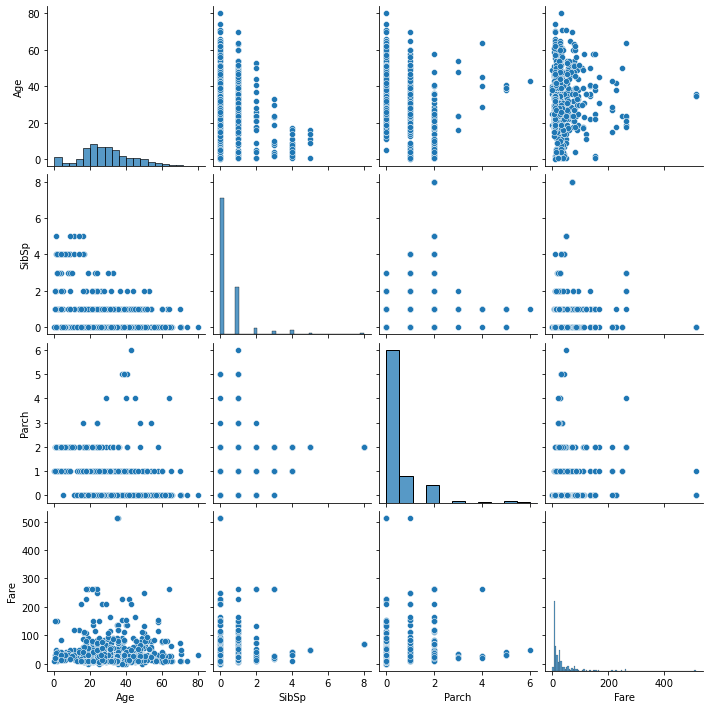

In [15]:
sns.pairplot(train)

## 2. Feature engineering

In [16]:
fe = pd.DataFrame()
# fe.index = train.index
fe["cabinArea"] = train["Cabin"].str[0]
fe["cabinArea"].fillna("Unknown",inplace=True)
pd.value_counts(fe["cabinArea"])

Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: cabinArea, dtype: int64

In [17]:
tickets = pd.DataFrame(train["Ticket"])
ticket_counts = train.groupby("Ticket").count()
ticket_max_counts = ticket_counts.max(axis=1)-1
ticket_max_counts = pd.DataFrame(ticket_max_counts).reset_index()
ticket_max_counts.rename(columns={0:"companions"},inplace=True)
tickets = tickets.merge(ticket_max_counts,how="left",on="Ticket")
tickets.index = train.index
fe["companions"] = tickets["companions"]

In [18]:
fe["prefix"] = train["Name"].str.split(",",expand=True)[1].map(lambda x: x.split(".")[0].strip())

prefixes_count = pd.DataFrame(fe["prefix"].value_counts()).reset_index()
prefixes_count.rename(columns={"index":"prefix","prefix":"count"},inplace=True)
prefixes_count

,prefix,count
0,Mr,517
1,Miss,182
2,Mrs,125
3,Master,40
4,Dr,7
5,Rev,6
6,Mlle,2
7,Major,2
8,Col,2
9,the Countess,1


In [19]:
low_prefixes_count = prefixes_count.loc[prefixes_count["count"]<40]
up_prefixes_names = list(prefixes_count.loc[prefixes_count["count"]>=40]["prefix"])
fepf = fe[fe["prefix"].isin(list(low_prefixes_count["prefix"]))]
tr_pf = train.iloc[fepf.index,:]
# tr_pf

In [20]:
others = list(fe["prefix"][~fe["prefix"].isin(up_prefixes_names)].unique())
fe["prefixCat"] = fe["prefix"].replace(others,"Other")

In [21]:
fe["SibSpParch"] = train["SibSp"] + train["Parch"]

In [35]:
train[train["Fare"]>500]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [64]:
from sklearn.ensemble import BaggingClassifier
from sklearn import svm,tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

trainX = train.copy(deep=True)
# trainX.dropna(axis=0,subset=["Embarked"],inplace=True)

trainX = trainX[trainX["Fare"]<=500]
# trainX["Pclass"] = trainX["Pclass"].astype(int)
# trainX["prefixCat"] = fe["prefix"]
# trainX["cabinArea"] = fe["cabinArea"]
# trainX["SibSpParch"] = fe["SibSpParch"]
# trainX["companions"] = fe["companions"]
trainX["Age"].fillna(trainX["Age"].median(),inplace=True)
trainX["Embarked"].fillna("Unknown",inplace=True)
trainX.drop(columns=["Name","Ticket","Cabin"],inplace=True)


# trainX.dropna(inplace=True)
# trainX = trainX.loc[:,~trainX.columns.duplicated()]

trainY = trainX.pop("Survived")



for v in trainX.columns:
    if trainX[v].dtype=="object":
        dum = pd.get_dummies(trainX[v],prefix=v+"_")
        dum.drop(columns=dum.columns[0],inplace=True)
        trainX = pd.concat([trainX,dum],axis=1).drop(columns=[v])

tt = trainX.copy()

# trainX = (trainX - trainX.mean(axis=0))/trainX.std(axis=0)
trainX = StandardScaler().fit_transform(trainX)


bagg = BaggingClassifier(base_estimator=svm.SVC(kernel="linear"), random_state=2)
# bagg = BaggingClassifier(base_estimator=LogisticRegression(), random_state=2)
scores = cross_val_score(bagg,trainX,trainY,cv=5)
# scores = cross_val_score(XGBClassifier(use_label_encoder=False,random_state=2),trainX,trainY.astype(int),cv=5)
print(scores.mean())
# scores

0.7889227448739922


In [52]:
train["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [51]:
trainX

array([[-0.56573646,  0.43279337, -0.47367361, ..., -0.30756234,
         0.61930636, -0.0474312 ],
       [ 0.66386103,  0.43279337, -0.47367361, ..., -0.30756234,
        -1.61470971, -0.0474312 ],
       [-0.25833709, -0.4745452 , -0.47367361, ..., -0.30756234,
         0.61930636, -0.0474312 ],
       ...,
       [-0.1046374 ,  0.43279337,  2.00893337, ..., -0.30756234,
         0.61930636, -0.0474312 ],
       [-0.25833709, -0.4745452 , -0.47367361, ..., -0.30756234,
        -1.61470971, -0.0474312 ],
       [ 0.20276197, -0.4745452 , -0.47367361, ...,  3.25137334,
        -1.61470971, -0.0474312 ]])

In [33]:
trainX = train.copy()

trainX = train.copy(deep=True)
trainX["Pclass"] = trainX["Pclass"].astype(int)
trainX["prefixCat"] = fe["prefix"]
# trainX["cabinArea"] = fe["cabinArea"]
# trainX["SibSpParch"] = fe["SibSpParch"]
trainX["companions"] = fe["companions"]
# trainX["Age"].fillna(trainX["Age"].mean(),inplace=True)
# trainX["Embarked"].fillna("Unknown",inplace=True)
trainX.drop(columns=["Name","Ticket","Cabin"],inplace=True)

# trainX.dropna(inplace=True)
# trainX = trainX.loc[:,~trainX.columns.duplicated()]
trainY = trainX.pop("Survived")
for v in trainX.columns:
    if trainX[v].dtype=="object":
        dum = pd.get_dummies(trainX[v],prefix=v+"_")
        trainX = pd.concat([trainX,dum],axis=1).drop(columns=[v])

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imp_mean = IterativeImputer(random_state=0)
trainX = imp_mean.fit_transform(trainX)

# trainX = (trainX - trainX.mean(axis=0))/trainX.std(axis=0)


bagg = BaggingClassifier(base_estimator=svm.SVC(kernel="linear"), random_state=2)
scores = cross_val_score(bagg,trainX,trainY,cv=5)
# scores = cross_val_score(XGBClassifier(use_label_encoder=False,random_state=2),trainX,trainY,cv=5)
print(scores.mean())
scores

0.8271420500910175


array([0.84357542, 0.8258427 , 0.81460674, 0.78651685, 0.86516854])